In [6]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, matthews_corrcoef
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

SENSOR_COLS = ["temperature", "heart_rate", "activity_index", "rumination_minutes"]

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
def generate_data(n_animals=200, n_hours=168, anomaly_rate=0.20, random_state=42):
    rng = np.random.default_rng(random_state)
    records = []

    for animal_id in range(n_animals):
        is_sick = rng.random() < anomaly_rate
        timestamps = pd.date_range("2024-01-01", periods=n_hours, freq="h")

        temp       = rng.normal(38.5, 0.3, n_hours)
        heart_rate = rng.normal(70,   5.0, n_hours)
        activity   = rng.normal(50,   8.0, n_hours)
        rumination = rng.normal(30,   5.0, n_hours)

        if is_sick:
            onset = rng.integers(n_hours // 3, 2 * n_hours // 3)
            temp[onset:]       += rng.normal(1.5, 0.4, n_hours - onset)
            heart_rate[onset:] += rng.normal(15,  3.0, n_hours - onset)
            activity[onset:]   -= rng.normal(20,  4.0, n_hours - onset)
            rumination[onset:] -= rng.normal(15,  3.0, n_hours - onset)

        for i, ts in enumerate(timestamps):
            records.append({
                "animal_id"          : animal_id,
                "timestamp"          : ts,
                "temperature"        : round(float(np.clip(temp[i],       36,  42)), 2),
                "heart_rate"         : round(float(np.clip(heart_rate[i], 40, 120)), 1),
                "activity_index"     : round(float(np.clip(activity[i],    0, 100)), 1),
                "rumination_minutes" : round(float(np.clip(rumination[i],  0,  60)), 1),
                "label"              : int(is_sick)
            })

    df = pd.DataFrame(records)
    sick = df.groupby("animal_id")["label"].first().sum()
    print(f"Rows: {len(df):,} | Animals: {n_animals} | Sick: {sick} | Healthy: {n_animals - sick}")
    return df

df = generate_data()
df.head(10)

Rows: 33,600 | Animals: 200 | Sick: 41 | Healthy: 159


,animal_id,timestamp,temperature,heart_rate,activity_index,rumination_minutes,label
0,0,2024-01-01 00:00:00,38.19,69.8,52.5,27.3,0
1,0,2024-01-01 01:00:00,38.73,66.7,59.2,42.1,0
2,0,2024-01-01 02:00:00,38.78,72.2,54.9,32.2,0
3,0,2024-01-01 03:00:00,37.91,67.7,31.7,27.2,0
4,0,2024-01-01 04:00:00,38.11,63.9,52.4,32.3,0
5,0,2024-01-01 05:00:00,38.54,63.6,50.6,22.2,0
6,0,2024-01-01 06:00:00,38.41,70.9,53.3,28.5,0
7,0,2024-01-01 07:00:00,38.49,77.9,62.9,30.5,0
8,0,2024-01-01 08:00:00,38.24,70.8,33.5,29.6,0
9,0,2024-01-01 09:00:00,38.76,69.4,45.3,34.0,0


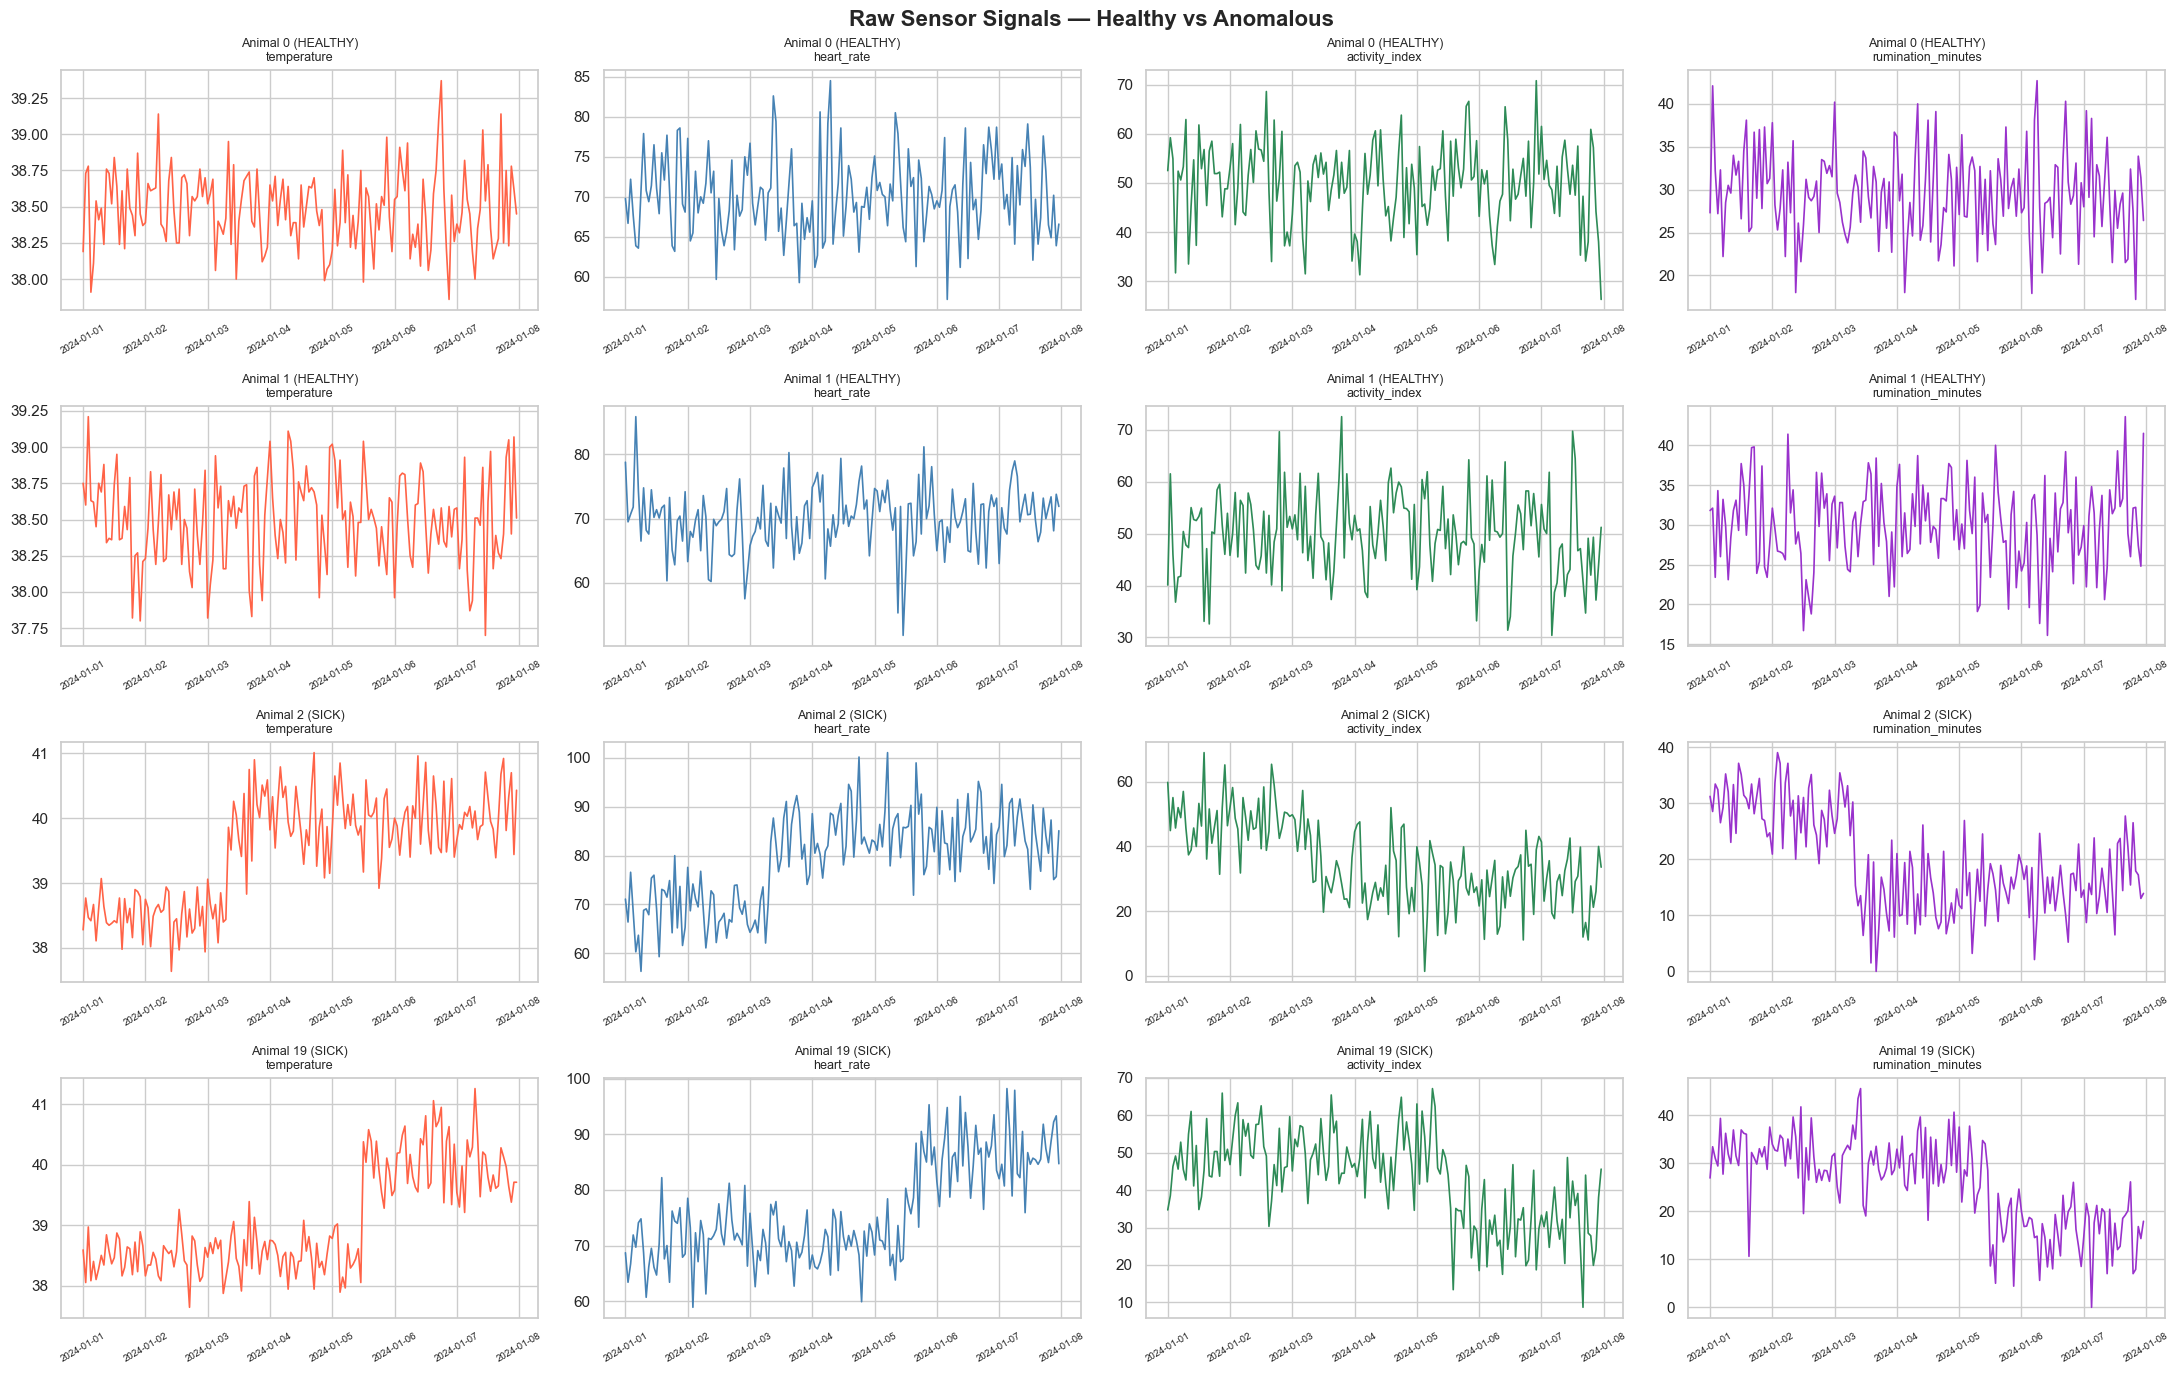

sensor_signals.png saved!


In [10]:
animal_labels = df.groupby("animal_id")["label"].first()
healthy_ids   = animal_labels[animal_labels == 0].index[:2].tolist()
sick_ids      = animal_labels[animal_labels == 1].index[:2].tolist()
plot_ids      = healthy_ids + sick_ids
colors        = ["tomato", "steelblue", "seagreen", "darkorchid"]

fig, axes = plt.subplots(4, 4, figsize=(22, 14))
fig.suptitle("Raw Sensor Signals — Healthy vs Anomalous", fontsize=16, fontweight="bold")

for row, aid in enumerate(plot_ids):
    sub = df[df["animal_id"] == aid].sort_values("timestamp")
    tag = "SICK" if sub["label"].iloc[0] == 1 else "HEALTHY"
    for col_i, (col, c) in enumerate(zip(SENSOR_COLS, colors)):
        ax = axes[row][col_i]
        ax.plot(sub["timestamp"], sub[col], color=c, lw=1.2)
        ax.set_title(f"Animal {aid} ({tag})\n{col}", fontsize=9)
        ax.tick_params(axis="x", rotation=30, labelsize=7)

plt.tight_layout()
plt.savefig("sensor_signals.png", dpi=130, bbox_inches="tight")
plt.show()
print("sensor_signals.png saved!")

In [11]:
def rolling_features(series, col, windows=[3, 6, 12, 24]):
    feats = {}
    for w in windows:
        roll = series.rolling(window=w, min_periods=1)
        feats[f"{col}_roll_mean_{w}h"] = roll.mean()
        feats[f"{col}_roll_std_{w}h"]  = roll.std().fillna(0)
        feats[f"{col}_roll_min_{w}h"]  = roll.min()
        feats[f"{col}_roll_max_{w}h"]  = roll.max()
    return feats

def trend_features(series, col, windows=[6, 12]):
    feats = {}
    for w in windows:
        slopes = []
        vals = series.values
        for i in range(len(vals)):
            seg   = vals[max(0, i - w + 1): i + 1]
            slope = np.polyfit(np.arange(len(seg)), seg, 1)[0] if len(seg) > 1 else 0.0
            slopes.append(slope)
        feats[f"{col}_trend_{w}h"] = slopes
    return feats

def rate_of_change(series, col, lags=[1, 3, 6]):
    feats = {}
    for lag in lags:
        feats[f"{col}_roc_{lag}h"] = series.pct_change(lag).fillna(0)
    return feats

def spike_features(series, col, z_thresh=2.5):
    mu  = series.expanding(min_periods=2).mean()
    sig = series.expanding(min_periods=2).std().replace(0, 1e-6).fillna(1)
    z   = (series - mu) / sig
    return {
        f"{col}_zscore"    : z.fillna(0),
        f"{col}_spike_flag": (z.abs() > z_thresh).astype(int)
    }

def variability_features(series, col, window=12):
    roll = series.rolling(window=window, min_periods=2)
    cv   = (roll.std() / roll.mean().replace(0, 1e-6)).fillna(0)
    iqr  = roll.quantile(0.75) - roll.quantile(0.25)
    return {
        f"{col}_cv_{window}h"  : cv,
        f"{col}_iqr_{window}h" : iqr.fillna(0)
    }

def engineer_features(df):
    print("Engineering features...")
    records = []
    for animal_id, group in df.groupby("animal_id"):
        group = group.sort_values("timestamp").reset_index(drop=True)
        fdict = {"animal_id": animal_id, "label": group["label"].iloc[0]}
        for col in SENSOR_COLS:
            s = group[col]
            fdict.update(rolling_features(s, col))
            fdict.update(trend_features(s, col))
            fdict.update(rate_of_change(s, col))
            fdict.update(spike_features(s, col))
            fdict.update(variability_features(s, col))
        scalar = {}
        for k, v in fdict.items():
            if k in ("animal_id", "label"):
                scalar[k] = v
            elif hasattr(v, "__len__"):
                arr = np.array(v, dtype=float)
                scalar[f"{k}_mean"] = np.nanmean(arr)
                scalar[f"{k}_max"]  = np.nanmax(arr)
            else:
                scalar[k] = v
        records.append(scalar)
    feat_df = pd.DataFrame(records).fillna(0)
    print(f"Done! Shape: {feat_df.shape[0]} animals x {feat_df.shape[1]-2} features")
    return feat_df

feat_df = engineer_features(df)
feat_df.head()

Engineering features...
Done! Shape: 200 animals x 200 features


,animal_id,label,temperature_roll_mean_3h_mean,temperature_roll_mean_3h_max,temperature_roll_std_3h_mean,temperature_roll_std_3h_max,temperature_roll_min_3h_mean,temperature_roll_min_3h_max,temperature_roll_max_3h_mean,temperature_roll_max_3h_max,...,rumination_minutes_roc_6h_mean,rumination_minutes_roc_6h_max,rumination_minutes_zscore_mean,rumination_minutes_zscore_max,rumination_minutes_spike_flag_mean,rumination_minutes_spike_flag_max,rumination_minutes_cv_12h_mean,rumination_minutes_cv_12h_max,rumination_minutes_iqr_12h_mean,rumination_minutes_iqr_12h_max
0,0,0,38.481806,39.073333,0.221019,0.592706,38.276369,38.75,38.697976,39.37,...,0.027618,0.622407,-0.103290,2.563449,0.005952,1.0,0.170669,0.301590,6.192113,10.675
1,1,0,38.497133,38.996667,0.251931,0.655973,38.254881,38.91,38.730655,39.21,...,0.040376,1.037267,-0.007651,2.554209,0.011905,1.0,0.173580,0.270579,6.460863,12.250
2,2,1,39.495546,40.566667,0.395907,1.018643,39.109762,40.34,39.868631,41.01,...,inf,inf,-0.642453,1.949032,0.035714,1.0,0.318579,0.665073,7.105208,17.575
3,3,0,38.548353,38.936667,0.274355,0.660404,38.284821,38.84,38.809107,39.18,...,0.030628,0.665272,-0.018565,2.342533,0.000000,0.0,0.151247,0.227245,5.926786,10.400
4,4,0,38.500347,39.000000,0.254677,0.637913,38.259345,38.80,38.744643,39.43,...,0.021176,0.696682,-0.069231,2.949065,0.023810,1.0,0.157965,0.343486,5.459226,10.225


In [13]:
X = feat_df.drop(columns=["animal_id", "label"])
y = feat_df["label"]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())
X = X.dropna(axis=1)
feature_names = X.columns.tolist()

print(f"Features: {X.shape[1]} | Class balance: {y.value_counts().to_dict()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Features: 200 | Class balance: {0: 159, 1: 41}
Train: 160 | Test: 40


In [14]:
pipelines = {
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))
    ]),
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
    ])
}

param_grids = {
    "RandomForest": {
        "clf__n_estimators"      : [100, 200],
        "clf__max_depth"         : [None, 10, 20],
        "clf__min_samples_split" : [2, 5]
    },
    "LogisticRegression": {
        "clf__C"      : [0.01, 0.1, 1, 10],
        "clf__penalty": ["l2"],
        "clf__solver" : ["lbfgs"]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_models = {}

for name, pipe in pipelines.items():
    print(f"Tuning {name}...")
    gs = GridSearchCV(pipe, param_grids[name], cv=cv, scoring="f1", n_jobs=-1, verbose=0)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    print(f"  Best Params : {gs.best_params_}")
    print(f"  CV F1 Score : {gs.best_score_:.4f}\n")

print("All models tuned!")

Tuning RandomForest...
  Best Params : {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
  CV F1 Score : 1.0000

Tuning LogisticRegression...
  Best Params : {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
  CV F1 Score : 1.0000

All models tuned!


In [15]:
print(f"{'Model':<25} {'Mean F1':>10} {'Std F1':>8}")
print("-" * 45)
for name, model in best_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>8.4f}")

Model                        Mean F1   Std F1
---------------------------------------------
RandomForest                  1.0000   0.0000
LogisticRegression            1.0000   0.0000


In [18]:
results = {}
for name, model in best_models.items():
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    results[name] = {
        "model"  : model,
        "y_pred" : y_pred,
        "y_prob" : y_prob,
        "f1"     : f1_score(y_test, y_pred),
        "mcc"    : matthews_corrcoef(y_test, y_pred),
        "roc_auc": auc(fpr, tpr),
        "avg_pr" : average_precision_score(y_test, y_prob)
    }
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["Healthy", "Anomaly"]))


  RandomForest
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        32
     Anomaly       1.00      1.00      1.00         8

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


  LogisticRegression
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        32
     Anomaly       1.00      1.00      1.00         8

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



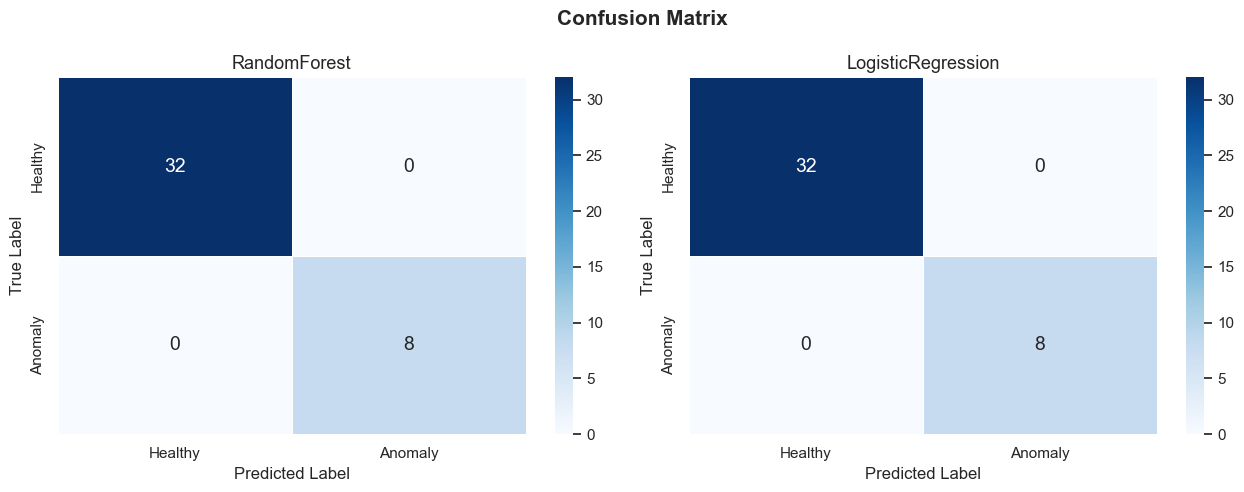

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrix", fontsize=15, fontweight="bold")

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Healthy", "Anomaly"],
                yticklabels=["Healthy", "Anomaly"],
                ax=ax, linewidths=0.5, annot_kws={"size": 14})
    ax.set_title(name, fontsize=13)
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=130, bbox_inches="tight")
plt.show()

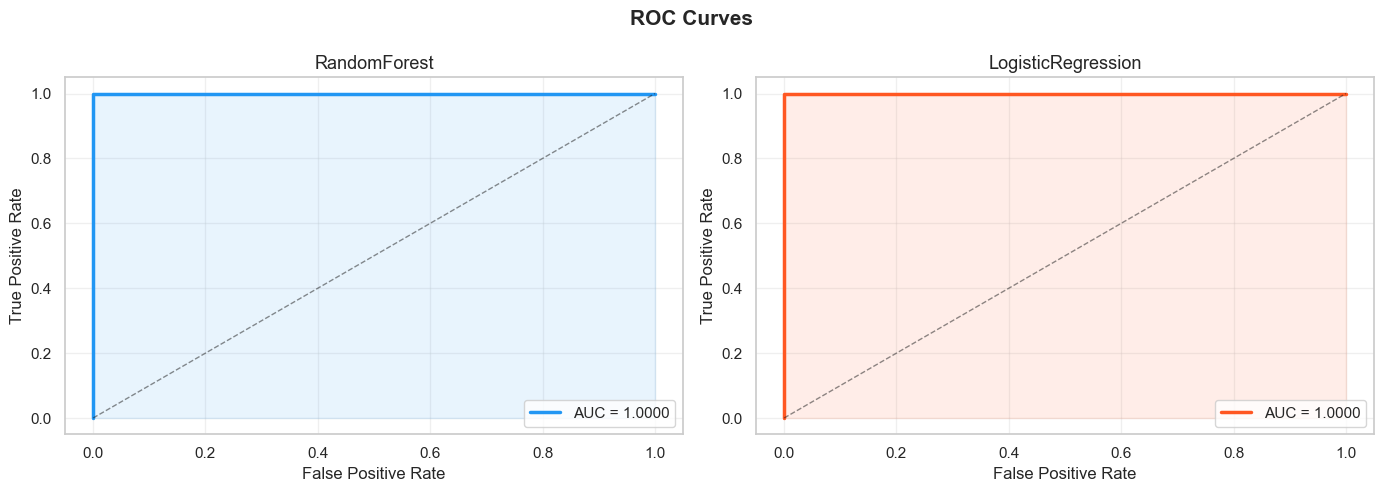

In [24]:
colors = ["#2196F3", "#FF5722"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ROC Curves", fontsize=15, fontweight="bold")

for ax, (name, res), c in zip(axes, results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=c, lw=2.5, label=f"AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.10, color=c)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(name, fontsize=13)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=130, bbox_inches="tight")
plt.show()

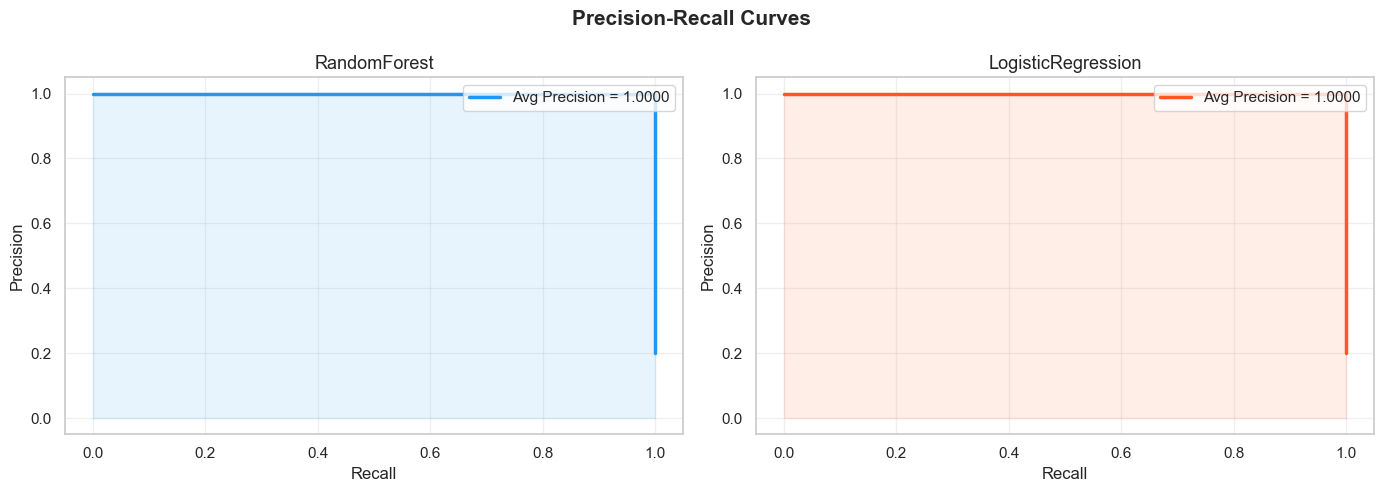

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Precision-Recall Curves", fontsize=15, fontweight="bold")

for ax, (name, res), c in zip(axes, results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    ap = average_precision_score(y_test, res["y_prob"])
    ax.plot(rec, prec, color=c, lw=2.5, label=f"Avg Precision = {ap:.4f}")
    ax.fill_between(rec, prec, alpha=0.10, color=c)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(name, fontsize=13)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pr_curves.png", dpi=130, bbox_inches="tight")
plt.show()

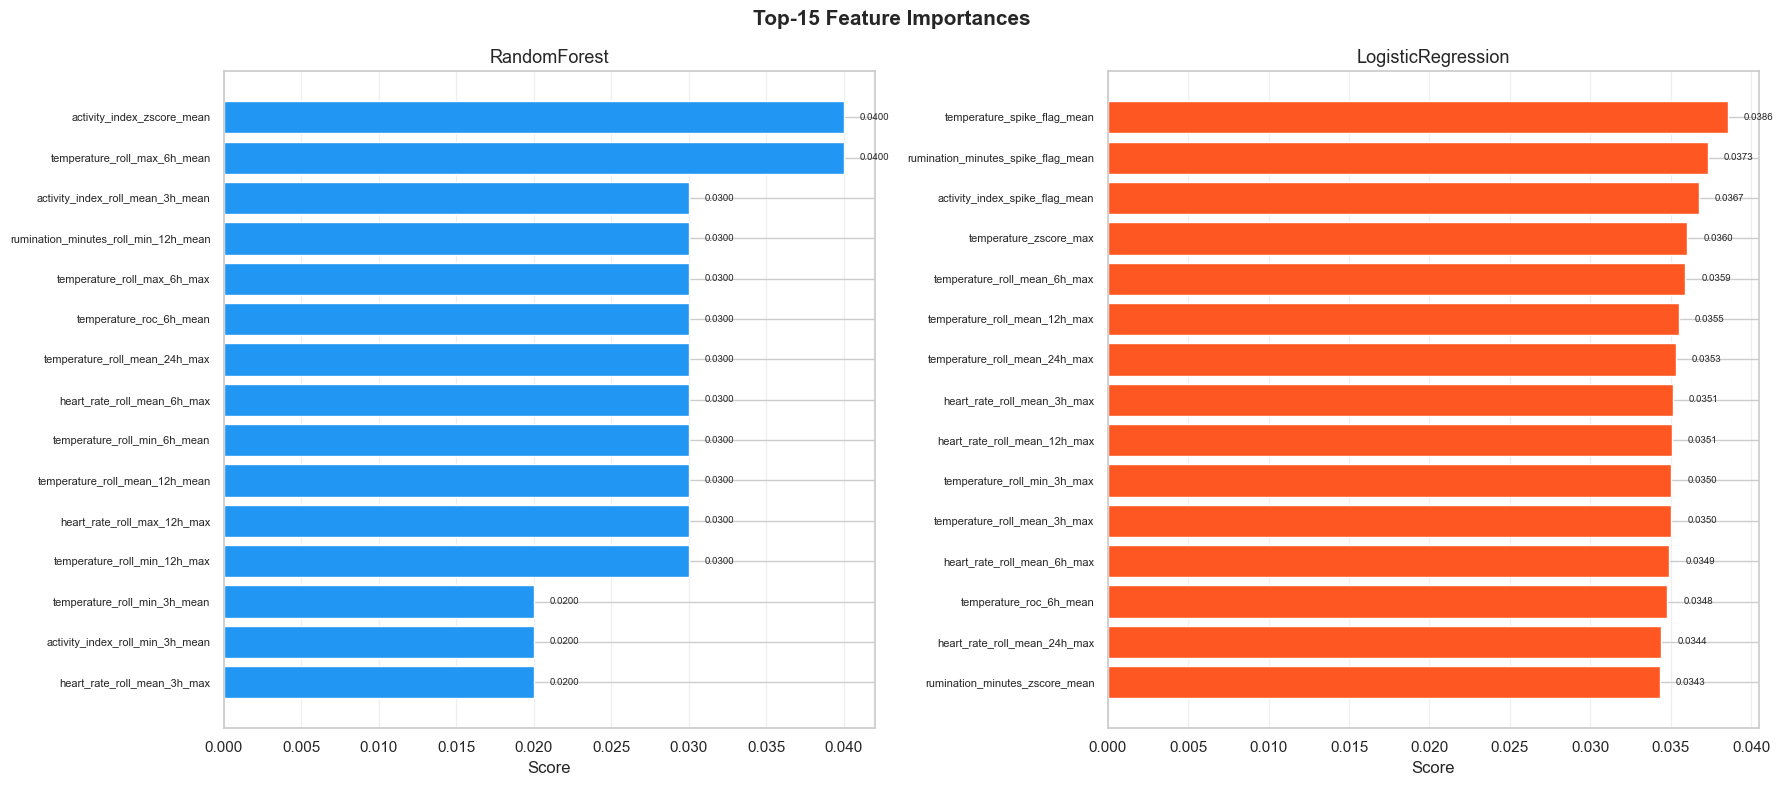

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Top-15 Feature Importances", fontsize=15, fontweight="bold")

for ax, (name, res), c in zip(axes, results.items(), colors):
    clf = res["model"].named_steps["clf"]
    scores = clf.feature_importances_ if hasattr(clf, "feature_importances_") else np.abs(clf.coef_[0])
    top_idx = np.argsort(scores)[-15:]
    bars = ax.barh([feature_names[i] for i in top_idx], scores[top_idx], color=c, edgecolor="white")
    for bar, val in zip(bars, scores[top_idx]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center", fontsize=7)
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Score")
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

In [30]:
print(f"\n{'='*60}")
print("  FINAL LEADERBOARD")
print(f"{'='*60}")
print(f"{'Model':<25} {'F1':>8} {'ROC-AUC':>10} {'MCC':>8} {'Avg-PR':>9}")
print("-" * 60)
for name, res in results.items():
    print(f"{name:<25} {res['f1']:>8.4f} {res['roc_auc']:>10.4f} {res['mcc']:>8.4f} {res['avg_pr']:>9.4f}")

best = max(results, key=lambda n: results[n]["roc_auc"])
print(f"\n  Best Model --> {best}  (ROC-AUC = {results[best]['roc_auc']:.4f})")
print("=" * 60)


  FINAL LEADERBOARD
Model                           F1    ROC-AUC      MCC    Avg-PR
------------------------------------------------------------
RandomForest                1.0000     1.0000   1.0000    1.0000
LogisticRegression          1.0000     1.0000   1.0000    1.0000

  Best Model --> RandomForest  (ROC-AUC = 1.0000)
